# Finding Curve of Best Fit

## Import libraries to project

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit

## Import data set

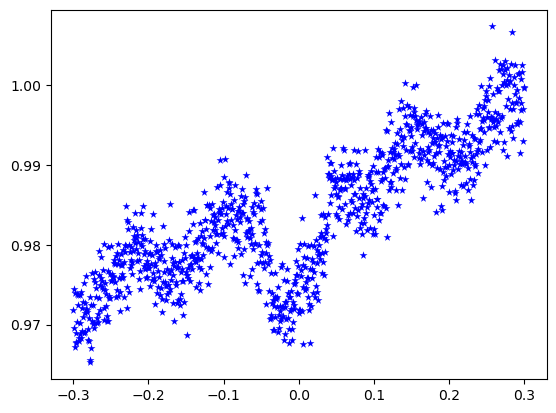

In [2]:
plcData = Table.read("Planet_Lightcurve.fits",format = "fits")
time = np.asarray(plcData["time [days]"])
flux = np.asarray(plcData["flux"])
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025)

## Define the mathematical functions to be used

$y = (m*x + b) + a * sin(f*x + s)$

Wherein m, b, a, f, and s are all constant parameters

In [3]:
def modelLine(x,m,b):
    '''
    Model a line using the given parameters
        The function of a line is equal to f(x) = mx + b
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
    Output
        y: 1d array with the same size as x, each value is equal to f(x)
    '''
    y = x * m
    y += b
    
    return y

def modelSine(x,amp,freq,shift):
    '''
    Model a sinusoid using the given parameters
        The function of a sinusoidal equation is equal to g(x) = amp * sin(freq * x + shift)
        
    Input
        x: 1d array of input values
        amp: amplitude of the sinusoid (how tall it is)
        freq: frequency of the sinusoid (how fast it repeats)
        shift: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #create the values to input into np.sin(), seperated visually for aesthetics and ease of comprehension
    inputValues = x * freq
    inputValues += shift
    y = np.sin(inputValues)
    y *= amp

    return y
def modelCombination(x,m,b,a,f,s):
    '''
    Model the addition of a sinusoid and a line
        The function of this combination is equal to h(x) = f(x) + g(x)
            Where f(x) and g(x) are the line and sinusoid respectively
        
    Input
        x: 1d array of input values
        m: slope of the line
        b: y intercept of the line
        a: amplitude of the sinusoid (how tall it is)
        f: frequency of the sinusoid (how fast it repeats)
        s: angle shift of the sinusoid (where it starts)
            (sine and cosine are actually the same function, however cosine is simply shifted forwards 90 degrees
            our sinusoid may not start at the g(0) = 0. For example, the sinusoid may start a third of the way through its oscillation)
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #model our line
    line = modelLine(x,m,b)
    #model our sinusoid
    sine = modelSine(x,a,f,s)
    y = line + sine
    return y

## Define the moving mean function, which is used to smoothen data

In [4]:
def movingMean(a, b, window, median = False):
    '''
    Utilizes a moving mean system to smoothen data

    Input
        a: first array of input data to be smoothed (typically some x coordinate)
        b: second array of input data to be smoothed (typically some y coordinate)
        window: integer size of each window that the function will use to smooth data
        median: boolean determining if the function should use median instead of mean
    Output
        smoothA: Array of the same size as a, data within is smoothed via moving mean
        smoothB: Array of the same size as a, data within is smoothed via moving mean
    '''
    smoothA = []
    smoothB = []

    #Check if we'll use median or mean
    if median:
        func = lambda arr: np.nanmedian(arr)
    else:
        func = lambda arr: np.nanmean(arr)

    #Loop
    i = 0
    while i < len(a):
        if(i <= int(window/2) or i >=len(a) - int(window/2)):
            #If too close to the edges, simply use the normal values
            smoothA.append(a[i])
            smoothB.append(b[i])
        else:
            #Otherwise, take the mean or median of the nearby values and append that to our array
            aMed = func(a[i:i+window])
            smoothA.append(aMed)
            bMed = func(b[i:i+window])
            smoothB.append(bMed)
        i +=1
    return np.asarray(smoothA), np.asarray(smoothB)

## Utilize the previously written functions to find the best fit

Text(0.5, 1.0, 'Planet Light Curve Best Fit Smoothed With Moving Mean')

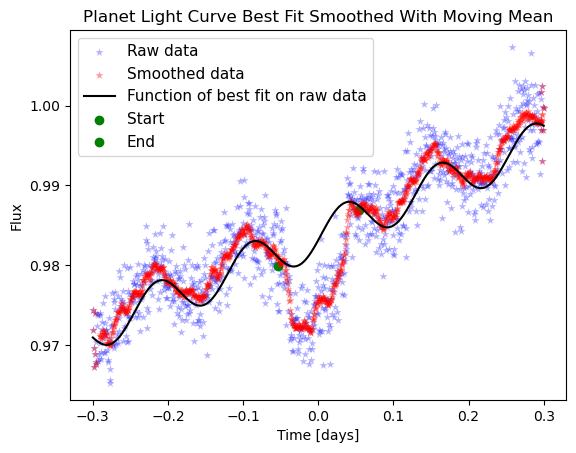

In [5]:
#smoothen out our data
timeSmoothed, fluxSmoothed = movingMean(time,flux,15)

#use scipy.curve_fit() to find a best fit with our smoothed data and the function
params, covariance = curve_fit(modelCombination, timeSmoothed, fluxSmoothed,p0=[1,1,1,50,0],sigma=0.003)

#plot raw data
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.3,zorder=1,label="Raw data")
#plot smoothed data
plt.scatter(timeSmoothed,fluxSmoothed,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Smoothed data")
#plot the calculated best fit
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*params), c='k', zorder=3,label='Function of best fit on raw data')

#plt.errorbar(time,flux,yerr=0.003,c='g',elinewidth=0.01,zorder=0)

plt.scatter(time[411],flux[411],c='g',label="Start")
plt.scatter(time[590],flux[590],c='g',label="End")


plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Planet Light Curve Best Fit Smoothed With Moving Mean")
#plt.savefig("PlanetLightCurveSmooth.pdf",format="pdf")

## Clear anomalous data to find the true curve of best fit

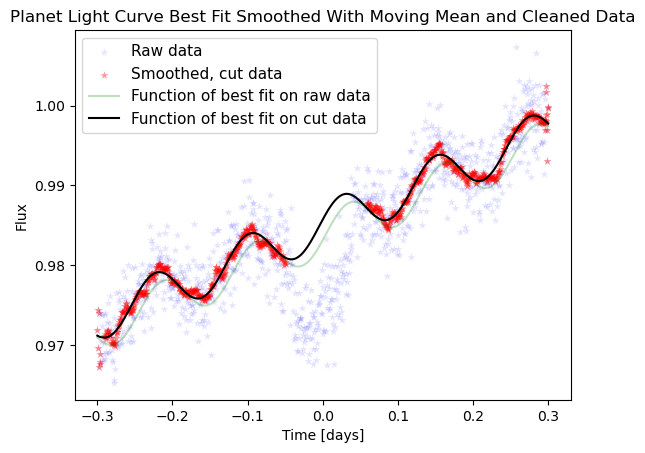

In [6]:
#A distinct anomaly can be found in the region [411:590] from the time and flux arrays
    #Most likely caused by the exoplanet's procession in front of the star
    #We cut the anomalous data, so as to experiment on 'clean' data
timeCutSmoothed = np.concatenate((timeSmoothed[0:411],timeSmoothed[590:]),0)
fluxCutSmoothed = np.concatenate((fluxSmoothed[0:411],fluxSmoothed[590:]),0)

#We find the new parameters based off of our cleaned data
paramsCut, covarianceCut = curve_fit(modelCombination, timeCutSmoothed, fluxCutSmoothed,p0=[1,1,1,50,0],sigma=0.003)

#Plot our various functions and data
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.1,zorder=0,label="Raw data")
plt.scatter(timeCutSmoothed,fluxCutSmoothed,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Smoothed, cut data")

plt.plot(timeSmoothed, modelCombination(timeSmoothed,*params), c='g', alpha=0.25, zorder=3,label='Function of best fit on raw data')
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*paramsCut), c='k', zorder=4,label='Function of best fit on cut data')

#Adjust our graph
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Planet Light Curve Best Fit Smoothed With Moving Mean and Cleaned Data")
plt.savefig("PlanetLightCurveCut.pdf",format="pdf")

# Finding Transit Depth

## Lock function curve to only search for 1 parameter

In [7]:
usedParams = paramsCut

def lockedModelCombination(x,b):
    '''
    Model the addition of a sinusoid and a line, accounting only for vertical shift as a variable parameter
        With m, a, f, and s as constant values not considered by the function
        The function of this combination is equal to h(x) = f(x) + g(x)
            Where f(x) and g(x) are the line and sinusoid respectively
        
    Input
        x: 1d array of input values
        b: y intercept of the line
    Output
        y: 1d array with the same size as x, each value is equal to g(x)
    '''
    #model our line
    line = modelLine(x,usedParams[0],b)
    #model our sinusoid
    sine = modelSine(x,usedParams[2],usedParams[3],usedParams[4])
    y = line + sine
    return y

## Grab cut-away data

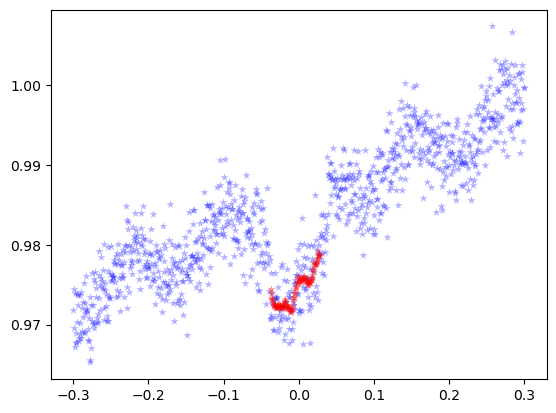

In [8]:
timeSectionSmooth = timeSmoothed[430:540]
fluxSectionSmooth = fluxSmoothed[430:540]
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.3,zorder=1,label="Raw data")
plt.scatter(timeSectionSmooth,fluxSectionSmooth,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Cut away data")

## Find shifted line of best fit

Text(0.5, 1.0, 'Comparison of Best Fit Curve and Shifted Curve During Exoplanet Transit')

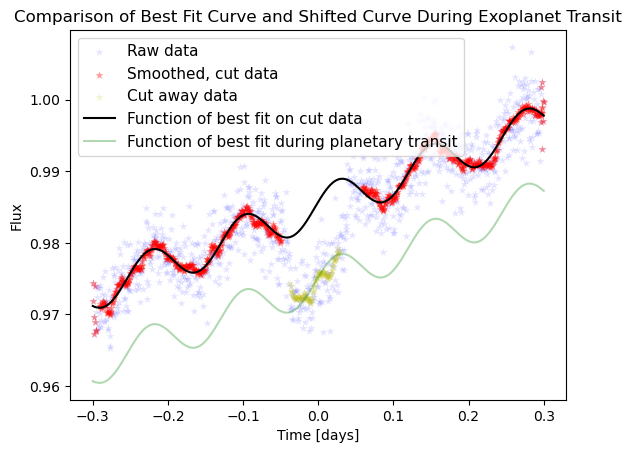

In [9]:
#Grab the new parameters for the section of transit
paramsSection, covarianceSection = curve_fit(lockedModelCombination, timeSectionSmooth, fluxSectionSmooth,p0=paramsCut[1],sigma=0.003)
#Plot data
plt.scatter(time,flux,c='b',marker='*',linewidth=0.0025,alpha=0.1,zorder=0,label="Raw data")
plt.scatter(timeCutSmoothed,fluxCutSmoothed,c='r',marker='*',linewidth=0.0025,alpha=0.4,zorder=2,label="Smoothed, cut data")
plt.scatter(timeSectionSmooth,fluxSectionSmooth,c='y',marker='*',linewidth=0.0025,alpha=0.2,zorder=2,label="Cut away data")

#Plot curve of best fit
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*paramsCut), c='k', zorder=3,label='Function of best fit on cut data')

#Set the new parameters, using the new value of b
newParams = paramsCut.copy()
newParams[1] = paramsSection[0]

#Plot the shifted graph
plt.plot(timeSmoothed, modelCombination(timeSmoothed,*newParams), c='g', alpha=0.3,zorder=4,label='Function of best fit during planetary transit')

#Grab transit depth
transitDepth = paramsCut[1] - newParams[1]

#Adjust our graph
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend(fontsize = 11)
plt.title("Comparison of Best Fit Curve and Shifted Curve During Exoplanet Transit")
#plt.savefig("CurveComparison.pdf",format="pdf")

### Unused functions

In [10]:
def calculateS(yData, yModel):
    '''
    Calculate sigmas for the data
    
    Input
        yData: 1d array_like, data points to fit model into
        yModel: 1d array_like with same length as yData. Model to compare against data

    Output
        S: sum of the residuals squared between models and data
    '''

    #calculate the residuals
    residuals = yData - yModel

    S = np.sum(residuals**2)
    return S

In [11]:
def findFit(xData,yData,p0,model,nSteps = 500, jumpSig=0.01):
    '''
    Find the best fit for h(x) = f(x) + g(x)
        wherein f(x) = m * x + b
        and g(x) = amp * sin(freq * x + shift)
            See modelline(), modelsine(), and modelCombination for details on these functions
    
    Input
        xData: 1d array-like, giving x-coordinates of dataset to be fitted
        yData: 1d array-like, giving y-coordinates of dataset to be fitted
        p0: array-like giving initial guess for the model
            wherein our guess is for all coefficients, [m,b,amp,freq,shift]
        model: model function to use
        nSteps (optional): int, number of steps for random walker. Default is 500
        jumpSig (optional): array-like, standard deviation to be used in random jump

    Output
        walk: nd-array of shape (nsteps+1,len(p0)) random walk where each step
            improves the fit from the last one
            
            walk[:,0] is all of the values of m
            walk[:,1] is all of the values of b
            walk[:,2] is all of the values of amp
            walk[:,3] is all of the values of freq
            walk[:,4] is all of the values of shift
            
        Ss: 1d-array of len(nSteps) + 1, gives the value of S for each step
    '''
    #create walk array filled with zeroes
        #length is nSteps+1 because the first value is equal to our initial guess
    walk = np.zeros(shape=(nSteps + 1, len(p0)))

    #set the first position equal to our initial guess
    walk[0,:] = p0

    #create empty array
    Ss = []

    #first value of S is the one from the initial guess
    Ss.append(calculateS(yData,model(xData,*p0)))

    i = 0
    while (len(Ss) < nSteps+1):
        #grab latest position
        previousPosition = walk[i,:]

        #making the jump be a gaussian with standard deviation sigma and mean of 0
        #the size should be len(p0) such that the variable jump can be applied to each coordinate at once
        jump = np.random.normal(scale = jumpSig, size = len(p0))

        #applying the jump to previousPosition, getting the new position of the walker
        newPosition = previousPosition + jump

        #calculate S after jump
        sJump =  calculateS(yData,model(xData,*newPosition))

        #if this S is smaller than the previous one, save it
        if sJump <= Ss[i]:
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sJump)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        elif np.random.random() < np.exp(Ss[i] - sJump):
            jumpSig /= 2
            #print("err:",i)
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sJump)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        else:
            continue
    
    #once the loop is over, return the walk to the user
    #Since we originally defined S as a python list, transform it to a numpy array
    return walk, np.asarray(Ss)

# Part 4

4) Using error propagation, find out what the root mean squared uncertainty in your measurement of D and the transit time is. Don't forget to take into account both the uncertainty in the data and the uncertainty from your fits. 

### Getting Root Mean Squared (RMS)

In [16]:

# TODO find actual values for D uncertainties and time uncertainties to plug into my function

def added_rms(data, fits):
    '''
    Purpose: Get root mean squared uncertainty of dataset (either transit depth D or transit time) taking into account data uncertainty and fits uncertainty. Follows Pythagoreon theorem
    Argument: data = data uncertainty. fits = fits uncertainty
    Returns: Combined root mean squared of dataset as numpy array
    ''' 
    # Convert arguments to numpy array
    data = np.array(data)
    fits = np.array(fits)
    # Square both uncertainties 
    data = data ** 2
    fits = fits ** 2
    # Add both uncertainties
    total = data + fits
    # Get square root of total
    total = total ** (1/2)
    return total

